In [15]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import datasets, transforms
import numpy as np
import copy
import math

### Utility functions

Useful functions...

In [16]:
def moving_avg(x, window=10):
    x = np.array(x)
    return np.convolve(x, np.ones(window)/window, mode="valid")

def show_reconstructions(rec_x_per_epoch,
                         save_path,
                         cmap="gray"):
    """
    rec_x_per_epoch:
        list of length num_epochs
        each element is a list of length batch_size
        each entry is a flattened (1024,) image

    Output layout:
        rows    = batch elements
        columns = epochs
    """

    num_epochs = len(rec_x_per_epoch)
    batch_size = len(rec_x_per_epoch[0])

    print(f"Saving reconstructions in {save_path}")
    print(f"Num rows: {batch_size}, columns: {epochs}")

    fig, axes = plt.subplots(
        batch_size,
        num_epochs,
        figsize=(num_epochs * 1.5, batch_size * 1.5),
        squeeze=False
    )

    for e in range(num_epochs):
        for b in range(batch_size):

            x_rec = rec_x_per_epoch[e][b]

            # handle torch tensors
            if hasattr(x_rec, "detach"):
                x_rec = x_rec.detach().cpu().numpy()

            x_rec = np.squeeze(x_rec)
            img = x_rec.reshape(28, 28)

            ax = axes[b, e]
            ax.imshow(img, cmap=cmap)

            ax.set_xticks([])
            ax.set_yticks([])

            # thin red border
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(0.5)

            # epoch label on top row
            if b == 0:
                ax.set_title(f"Ep. {e+1}", fontsize=28, pad=2)

    # remove all spacing
    plt.subplots_adjust(
        left=0,
        right=1,
        top=1,
        bottom=0,
        wspace=0.03,
        hspace=0
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

def total_variation_loss(x, height=28, width=28):
    """
    Batched Total Variation Loss.

    Args:
        x: torch.Tensor of shape
            (B, H*W)      or
            (B, 1, H, W)

    Returns:
        scalar tensor = mean TV across batch
    """

    # if flattened → reshape
    if x.dim() == 2:
        B = x.size(0)
        img = x.view(B, 1, height, width)

    # already image-shaped
    elif x.dim() == 4:
        img = x

    else:
        raise ValueError("x must be (B,H*W) or (B,1,H,W)")

    # horizontal & vertical diffs
    diff_h = img[:, :, :, 1:] - img[:, :, :, :-1]
    diff_v = img[:, :, 1:, :] - img[:, :, :-1, :]

    # TV per image
    tv_per_img = (
        diff_h.pow(2).sum(dim=(1,2,3)) +
        diff_v.pow(2).sum(dim=(1,2,3))
    )

    # mean over batch
    return tv_per_img.mean()



Next, we define our simple MLP model. It consists of
* one hidden dimension of size 256 and
* ReLU activations.

In [42]:
def grad_norm(model, norm_type=2):
    """
    Computes the norm of gradients of all parameters in a model.

    Args:
        model (nn.Module): PyTorch model with computed gradients
        norm_type (float): type of norm (2 for L2, 1 for L1, float('inf') for max)

    Returns:
        float: gradient norm
    """
    total_norm = 0.0

    if norm_type == float('inf'):
        total_norm = max(
            p.grad.abs().max().item()
            for p in model.parameters()
            if p.grad is not None
        )
        return total_norm

    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(norm_type)
            total_norm += param_norm.item() ** norm_type

    total_norm = total_norm ** (1.0 / norm_type)
    return total_norm


class MLP(nn.Module):
    '''
    Multi-Layer perceptron
    '''
    def __init__(self, input_dim, output_dim, hidden_dim=256):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return (self.layers(x))

Next we preprocess our dataset. The dataset we use is a random subset of size $n$ of the [MNIST](http://yann.lecun.com/exdb/mnist/) dataset. 

In [18]:
def prepare_mnist(n):
    '''
    Loads and prepares the MNIST dataset. Takes as input the number of training points n and return X, y, means. 
    '''

    # Define transform: convert to tensor [0,1] and flatten to 784-dim vector
    transform = transforms.Compose([
        transforms.ToTensor(),                      # -> (1, 28, 28), values in [0,1]
        transforms.Lambda(lambda x: x.view(-1))     # -> (784,)
    ])

    # Load the training dataset
    train_dataset = datasets.MNIST(root='../data/mnist', train=True, download=True, transform=transform)

    # Load the test dataset
    test_dataset = datasets.MNIST(root='../data/mnist', train=False, download=True, transform=transform)
    # Pick a smaller subset of training data (e.g. 5000 samples)
    subset_size = n
    indices = torch.randperm(len(train_dataset))[:subset_size]  # random subset
    train_dataset = Subset(train_dataset, indices)

    # Convert subset to arrays X, y
    X = []
    y = []
    for i in range(len(train_dataset)):
        data, label = train_dataset[i]
        X.append(data.numpy())   # convert tensor -> numpy
        y.append(label)

    X = np.stack(X)   # shape (n, 784)

    y = np.array(y)   # shape (n,)

    means = []
    M=10
    for c in range(M):
        class_samples = X[y == c]
        class_mean = np.mean(class_samples, axis=0)
        means.append(class_mean)

    means = np.array(means)   # shape (10, 784)

    return X, y, means 

def prepare_data_loader(X, y, batch_size=1):
    '''
    Prepares the data loader and returns it.
    Input: - X: the data.
           - y: the labels of the data.
           - batch_size. Default is 1.
    Returns: a DataLoader object ready for training and one for testing and the total number of training data.
    '''
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                  torch.tensor(y_train, dtype=torch.long))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                 torch.tensor(y_test, dtype=torch.long))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    total_samples = len(train_loader) * train_loader.batch_size

    return train_loader, test_loader, total_samples


def get_cifar10_subset_mlp_dataloaders(n_train=4000, n_test=1000, batch_size=1, data_dir="../data", seed=42):
    """
    Returns subset DataLoaders of CIFAR-10 for MLP training.

    Returns:
        train_loader, test_loader
    """

    transform = transforms.Compose([
        transforms.ToTensor(),

        transforms.Lambda(lambda x: x.view(-1))  # flatten 32×32×3 → 3072
    ])

    train_dataset = datasets.CIFAR10(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.CIFAR10(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

    # Reproducible subset selection
    generator = torch.Generator().manual_seed(seed)

    train_indices = torch.randperm(len(train_dataset), generator=generator)[:n_train]
    test_indices = torch.randperm(len(test_dataset), generator=generator)[:n_test]

    train_subset = Subset(train_dataset, train_indices)
    test_subset = Subset(test_dataset, test_indices)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader

train_loader, test_loader = get_cifar10_subset_mlp_dataloaders()
#train_loader , test_loader, total_samples = prepare_data_loader(X, y)

for X, y in train_loader:
    print(X.shape)
    break

torch.Size([1, 3072])


## Train the model 


In [19]:
def train(epochs, optimizer, loss_function):
    loss_per_epoch = []
    test_acc_per_epoch = []
    train_acc_per_epoch = []
    for epoch in range(epochs):
        model.train()
        tot_loss = 0
        correct, total = 0, 0
        for i, data in enumerate(train_loader, 0):
            x_batch, y_batch = data
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = loss_function(outputs, y_batch)
            loss.backward()
            optimizer.step()
            tot_loss += loss.item()

            outputs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        loss_per_epoch.append(tot_loss)
        train_acc_per_epoch.append(correct/total)
    
        # Evaluate after each epoch
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                outputs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
            acc = correct / total
            test_acc_per_epoch.append(acc)
    
        print(f"Epoch {epoch+1}: Test acc: {test_acc_per_epoch[epoch]:.4f}, train acc: {train_acc_per_epoch[epoch]:.4f}, epoch loss: {loss_per_epoch[epoch]:.4f}")
    
    return test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, tot_loss


In [15]:
model = MLP(X.shape[1], 10)
loss_function = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
#epochs = 15
epochs = 70

test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, cummulative_loss = train(epochs, optimizer, loss_function)

Epoch 1: Test acc: 0.2590, train acc: 0.1715, epoch loss: 8660.3774
Epoch 2: Test acc: 0.2950, train acc: 0.2550, epoch loss: 8079.8093
Epoch 3: Test acc: 0.2080, train acc: 0.2888, epoch loss: 7768.3307
Epoch 4: Test acc: 0.3350, train acc: 0.3078, epoch loss: 7576.5210
Epoch 5: Test acc: 0.3180, train acc: 0.3177, epoch loss: 7435.1466
Epoch 6: Test acc: 0.3420, train acc: 0.3295, epoch loss: 7286.6386
Epoch 7: Test acc: 0.3400, train acc: 0.3435, epoch loss: 7145.8089
Epoch 8: Test acc: 0.3610, train acc: 0.3510, epoch loss: 7038.6245
Epoch 9: Test acc: 0.3530, train acc: 0.3580, epoch loss: 6943.8117
Epoch 10: Test acc: 0.3270, train acc: 0.3845, epoch loss: 6803.0868
Epoch 11: Test acc: 0.3400, train acc: 0.3967, epoch loss: 6622.7805
Epoch 12: Test acc: 0.3440, train acc: 0.4140, epoch loss: 6514.7349
Epoch 13: Test acc: 0.3630, train acc: 0.4108, epoch loss: 6466.3371
Epoch 14: Test acc: 0.3730, train acc: 0.4255, epoch loss: 6305.6246
Epoch 15: Test acc: 0.3440, train acc: 0.44

### Plot the reuslts 

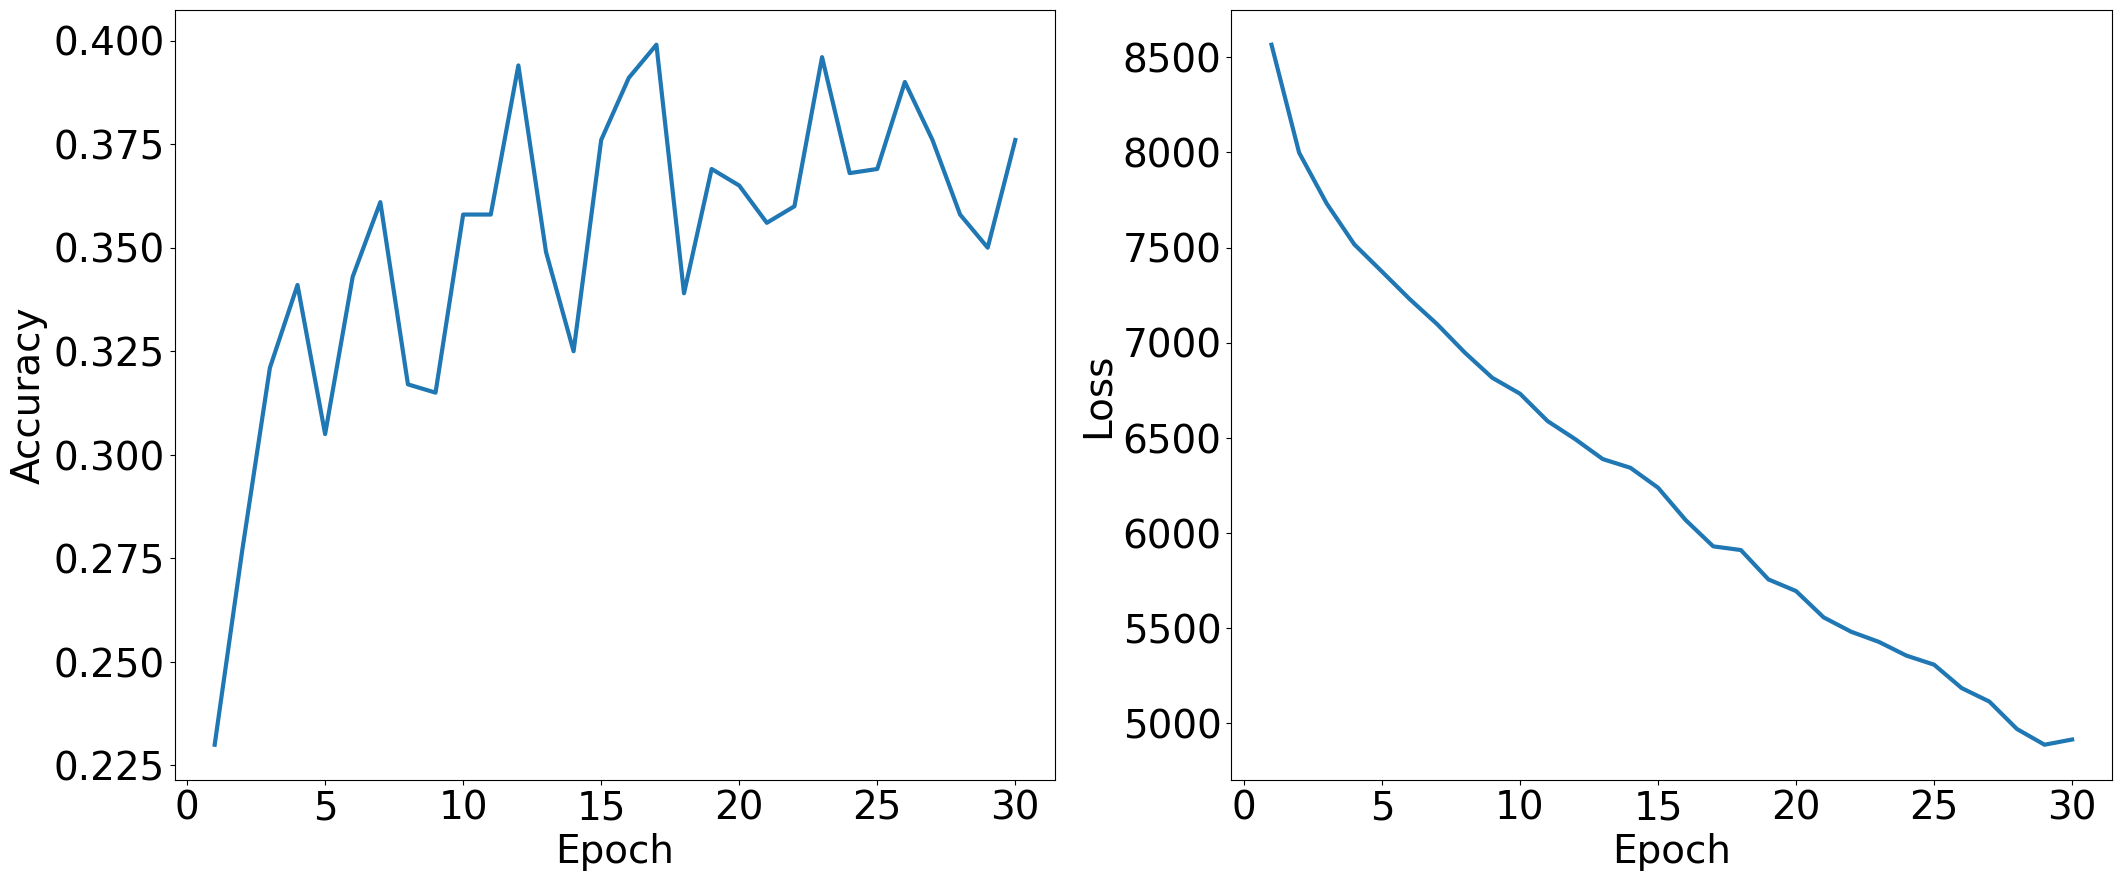

In [14]:
plt.figure(figsize=(25, 10))
plt.rcParams.update({'font.size': 28})
plt.subplot(1,2,1)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(range(1, epochs+1), test_acc_per_epoch , linestyle='-', linewidth=3, label='noisless')

plt.subplot(1,2,2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(range(1, epochs+1), loss_per_epoch , linestyle='-', linewidth=3, label='noisless')

plt.show()


# Add noise to the gradients.

Now we perform the same experiments, in the same setup but we add noise to the gradients of a fixed SNR, i.e. $SNR = \frac{\|grad\|}{\sigma^2 |\nabla|}$, then we compare with the noiseless model.

In [20]:
def get_grad_vector(grad):
    """
    Returns all gradients of model parameters as a single flattened vector.
    Assumes backward() has already been called.
    """
    grad_list = []

    for param in grad:
        if param.grad is not None:
            grad_list.append(param.grad.view(-1))
        else:
            # If a parameter has no gradient, append zeros of same size
            grad_list.append(torch.zeros_like(param).view(-1))

    return torch.cat(grad_list)


In [40]:
def cross_entropy_for_onehot(pred, target):
    return torch.mean(torch.sum(- target * F.log_softmax(pred, dim=-1), 1))

def add_noise_to_grads(model, snr):
    # Compute gradient norm and size
    grad_sq_sum = 0.0
    num_elems = 0
    grad_tuple = []

    for p in model.parameters():
        if p.grad is not None:
    
            if not torch.isfinite(p.grad).all():
                p.grad.data = torch.nan_to_num(
                    p.grad.data,
                    nan=0.0,
                    posinf=1e4,
                    neginf=-1e4
                )
    
            grad_sq_sum += torch.sum(p.grad.data ** 2)
            num_elems += p.grad.numel()
       
    # Compute sigma from SNR
    if snr != None:
        rms_grad = torch.sqrt(grad_sq_sum / num_elems + 1e-8)
        sigma = rms_grad / torch.sqrt(torch.tensor(snr + 1e-8))
        sigma = torch.clamp(sigma, min=1e-8, max=100.0)
        if math.isnan(sigma):
            sigma = 1e12
    else:
        sigma = 1e12 # infinity (Very very large)
        
    # Add Gaussian noise to each gradient
    for p in model.parameters():
        if p.grad is not None:
            noise = torch.randn_like(p.grad) * sigma
            if snr != None:
                p.grad.add_(noise)
            
            grad_tuple.append(p.grad)
            
    grad = tuple(g.detach().clone() for g in grad_tuple)
    #grad_tuple = tuple(grad_tuple)
    return sigma, grad_tuple

    
def dlg_attack(original_dy_dx, model, criterion=cross_entropy_for_onehot, loss_function="grad_diff", batch_size=1):
    '''
    iDLG attack.
    original_dy_dx: the gradient of the model's training shared to the clients.
    model: the model to be attacked
    criterion: the loss funtion used by the model
    loss_funtion: the loss funtion used by th attack. 'grad_diif' is the original, 'cosine similarity' for the cosine similarity loss funtion.
    '''
    # generate dummy data and label
    dummy_data = torch.randn((batch_size,784)).requires_grad_(True)
    dummy_label = torch.randn((batch_size,10), requires_grad=True)
    optimizer = torch.optim.Adam([dummy_data, dummy_label], lr=0.1)
    #optimizer = torch.optim.LBFGS([dummy_data,], lr=1)
    #criterion_iDLG = nn.CrossEntropyLoss()

    history = []
    convergance = 1e10
    prev_loss = 1e10
    current_loss = 1e10
    iters = 0
    lambda_tv = 1e-4
    while (iters < 3000 and current_loss>1e-3):
        if iters != 0:
            prev_loss = current_loss
        def closure():
            optimizer.zero_grad()
    
            pred = model(dummy_data)
            dummy_onehot_label = F.softmax(dummy_label, dim=-1)
            #last_bias_grad = original_dy_dx[-1]   
            #label_pred = torch.argmin(last_bias_grad).view(1)
            #dummy_loss = criterion_iDLG(pred, label_pred)
            dummy_loss = criterion(pred, dummy_onehot_label) 
            dummy_dy_dx = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)

            grad_diff = 0
            grad_count = 0
            total = 0
            lambda_tv = 1e-5
            tv_loss = total_variation_loss(dummy_data,  height=28, width=28)
            if loss_function=='cosine similarity':   
                for gx, gy in zip(dummy_dy_dx, original_dy_dx):
                    cos = F.cosine_similarity(gx.reshape(1, -1), gy.reshape(1, -1), eps=1e-8)
                    
                    n = gy.numel()
                    #grad_diff += n * (1 - cos)
                    grad_diff += (1 - cos)
                    total += n
                
                #grad_diff = grad_diff / total
                grad_diff = grad_diff + lambda_tv * tv_loss

            elif loss_function == 'nDLG':
                for gx, gy in zip(dummy_dy_dx, original_dy_dx): 
                    n = gy.numel()
                    gx_norm = torch.norm(gx, p=2)
                    gy_norm = torch.norm(gy, p=2)
    
                    gx_normalized = gx / (gx_norm)
                    gy_normalized = gy / (gy_norm)
    
                    grad_diff += ((gx_normalized - gy_normalized) ** 2).sum()
                    total += n
                #grad_diff = grad_diff / total
                grad_diff += lambda_tv * tv_loss
            else:
                for gx, gy in zip(dummy_dy_dx, original_dy_dx): 
                    n = gy.numel()
                    grad_diff += ((gx - gy) ** 2).sum()
                    total += n
                #grad_diff = grad_diff / total
                grad_diff += lambda_tv * tv_loss

            grad_diff.backward()
    
            return grad_diff
    
        current_loss = optimizer.step(closure)
        dummy_data.data.clamp_(0,1)
        dummy_label.data.clamp_(-10,10)
        current_loss = current_loss.item()
        convergance = np.abs(current_loss - prev_loss)/np.abs(current_loss)
        history.append(dummy_data.cpu())
        iters += 1
       
    print(f'Iters: {iters}, Loss: {current_loss:.4f}, Convergance value: {convergance:.6f}')
    return history

def noisy_train(model, train_loader, test_loader, epochs, optimizer, loss_function, snr, attack='grad_diff', batch_size=1):
    loss_per_epoch = []
    test_acc_per_epoch = []
    train_acc_per_epoch = []
    rec_x_per_epoch = []
    rec_error_per_epoch = []
    grad_norm_per_epoch = []
    
    
    for epoch in range(epochs):
        model.train()
        tot_loss = 0
        correct, total = 0, 0
        rec_error, sigma = 0.0, 0.0

        rec_error_per_epoch.append([])
        grad_norm_per_epoch.append([])
        for i, data in enumerate(train_loader, 0):
            x_batch, y_batch = data
            optimizer.zero_grad()

            outputs = model(x_batch)
            loss = loss_function(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
            sigma, grad = add_noise_to_grads(model, snr) # Here we calculate std based on snr and add noise to gradients.
            
            # Perform attack. 
            if (i == 0): 
                # Share the gradients with clients.
                # Make a deep copy of the model so we avoid conflicts with backpropagation.
                frozen_model = copy.deepcopy(model).eval()

                # Try the attack many times to avoid bad reconstructions due to bad initialization of data.
                rec_error = 0.0
                for trial in range(1):    
                    history = dlg_attack(grad, frozen_model, loss_function=attack, batch_size=batch_size)

                    rec_x_batched = history[-1].detach()
                    rec = rec_x_batched.view(batch_size, -1)
                    x = x_batch.detach().view(batch_size, -1)
                    
                    sim = F.cosine_similarity(rec, x, dim=1)
                    rec_error = sim.mean().item()
                    if rec_error > 0.6:
                        break 
                
                if i == 0:
                    rec_x_per_epoch.append(rec)
                rec_error_per_epoch[epoch].append(rec_error)
                grad_norm_per_epoch[epoch].append(grad_norm(model))
                print(f'Iter: {i+1}, rec_error: ', rec_error, f',grad L2 norm: {grad_norm_per_epoch[epoch][-1]}, Sigma: {sigma}')
            
            optimizer.step()
    

            tot_loss += loss.item()

            outputs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        

        loss_per_epoch.append(tot_loss)
        train_acc_per_epoch.append(correct / total)

        # Evaluation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                outputs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

        acc = correct / total
        test_acc_per_epoch.append(acc)
        
        print(f"Epoch {epoch+1}: Test acc: {acc:.4f}, train acc: {train_acc_per_epoch[epoch]:.4f}, epoch loss: {loss_per_epoch[epoch]:.4f}, reconstruction error: {rec_error:.4f}")

    show_reconstructions(rec_x_per_epoch, f"./grid{batch_size}_{attack}_{snr}.png")
    error_grads = (rec_error_per_epoch, grad_norm_per_epoch)
    return test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, tot_loss, rec_x_per_epoch, error_grads

In [ ]:
B=1
X, y, means = prepare_mnist(5000)
train_loader , test_loader, total_samples = prepare_data_loader(X, y, batch_size=B)

epochs = 15
snr = 1e-4

model = MLP(X.shape[1], 10, hidden_dim=512)
loss_function = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
noisy_test_acc_per_epoch, noisy_train_acc_per_epoch, noisy_loss_per_epoch, noisy_cummulative_loss, noisy_rec_x_per_epoch, error_grads = noisy_train(model, train_loader, test_loader, 
                                                                                                                                           epochs, optimizer, loss_function, snr, attack='cosine similarity', batch_size=B)
errors = np.array(error_grads[0])
grads = np.array(error_grads[1])

In [52]:
#snr_arr = [0.01, 0.1, 1, None]
snr_arr = [None]
B=16
epochs=15
X, y, means = prepare_mnist(5000)
train_loader , test_loader, total_samples = prepare_data_loader(X, y, batch_size=B)

errors_snr_nDLG = []
for i, snr in enumerate(snr_arr):
    torch.manual_seed(0)
    print(f'Starting training for snr: {snr} and nDLG')
    
    model = MLP(X.shape[1], 10, hidden_dim=512)
    loss_function = nn.CrossEntropyLoss(reduction="mean")
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    noisy_test_acc_per_epoch, noisy_train_acc_per_epoch, noisy_loss_per_epoch, noisy_cummulative_loss, noisy_rec_x_per_epoch, error_grads = noisy_train(model, train_loader, test_loader, 
                                                                                                                                               epochs, optimizer, loss_function, snr, attack='nDLG',
                                                                                                                                                       batch_size=B)
    errors = np.array(error_grads[0])
    grads = np.array(error_grads[1])

    errors_snr_nDLG.append(errors)

errors_snr_cos = []
for i, snr in enumerate(snr_arr):
    torch.manual_seed(0)
    print(f'Starting training for snr: {snr} and cosine similarity')
    
    model = MLP(X.shape[1], 10, hidden_dim=512)
    loss_function = nn.CrossEntropyLoss(reduction="mean")
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    noisy_test_acc_per_epoch, noisy_train_acc_per_epoch, noisy_loss_per_epoch, noisy_cummulative_loss, noisy_rec_x_per_epoch, error_grads = noisy_train(model, train_loader, test_loader, 
                                                                                                                                               epochs, optimizer, loss_function, snr, attack='cosine similarity',
                                                                                                                                                       batch_size=B)
    errors = np.array(error_grads[0])
    grads = np.array(error_grads[1])

    errors_snr_cos.append(errors)

errors_snr_iDLG = []
for i, snr in enumerate(snr_arr):
    torch.manual_seed(0)
    print(f'Starting training for snr: {snr} and DLG')
    
    model = MLP(X.shape[1], 10, hidden_dim=512)
    loss_function = nn.CrossEntropyLoss(reduction="mean")
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    noisy_test_acc_per_epoch, noisy_train_acc_per_epoch, noisy_loss_per_epoch, noisy_cummulative_loss, noisy_rec_x_per_epoch, error_grads = noisy_train(model, train_loader, test_loader, 
                                                                                                                                               epochs, optimizer, loss_function, snr, attack='iDLG',
                                                                                                                                                       batch_size=B)
    errors = np.array(error_grads[0])
    grads = np.array(error_grads[1])

    errors_snr_iDLG.append(errors)

Starting training for snr: None and nDLG
Iters: 3000, Loss: 0.3486, Convergance value: 0.006265
Iter: 1, rec_error:  0.4901175796985626 ,grad L2 norm: 0.3595969877263425, Sigma: 1000000000000.0
Epoch 1: Test acc: 0.2640, train acc: 0.1537, epoch loss: 572.6344, reconstruction error: 0.4901
Iters: 3000, Loss: 0.2240, Convergance value: 0.122974
Iter: 1, rec_error:  0.4834347069263458 ,grad L2 norm: 0.44239897451548665, Sigma: 1000000000000.0
Epoch 2: Test acc: 0.3970, train acc: 0.3063, epoch loss: 560.7930, reconstruction error: 0.4834
Iters: 3000, Loss: 0.3506, Convergance value: 0.102123
Iter: 1, rec_error:  0.49389007687568665 ,grad L2 norm: 0.5409047129060718, Sigma: 1000000000000.0
Epoch 3: Test acc: 0.5430, train acc: 0.4597, epoch loss: 520.0871, reconstruction error: 0.4939
Iters: 3000, Loss: 0.3507, Convergance value: 0.010172
Iter: 1, rec_error:  0.4910135865211487 ,grad L2 norm: 1.237422705988895, Sigma: 1000000000000.0
Epoch 4: Test acc: 0.6610, train acc: 0.6302, epoch los

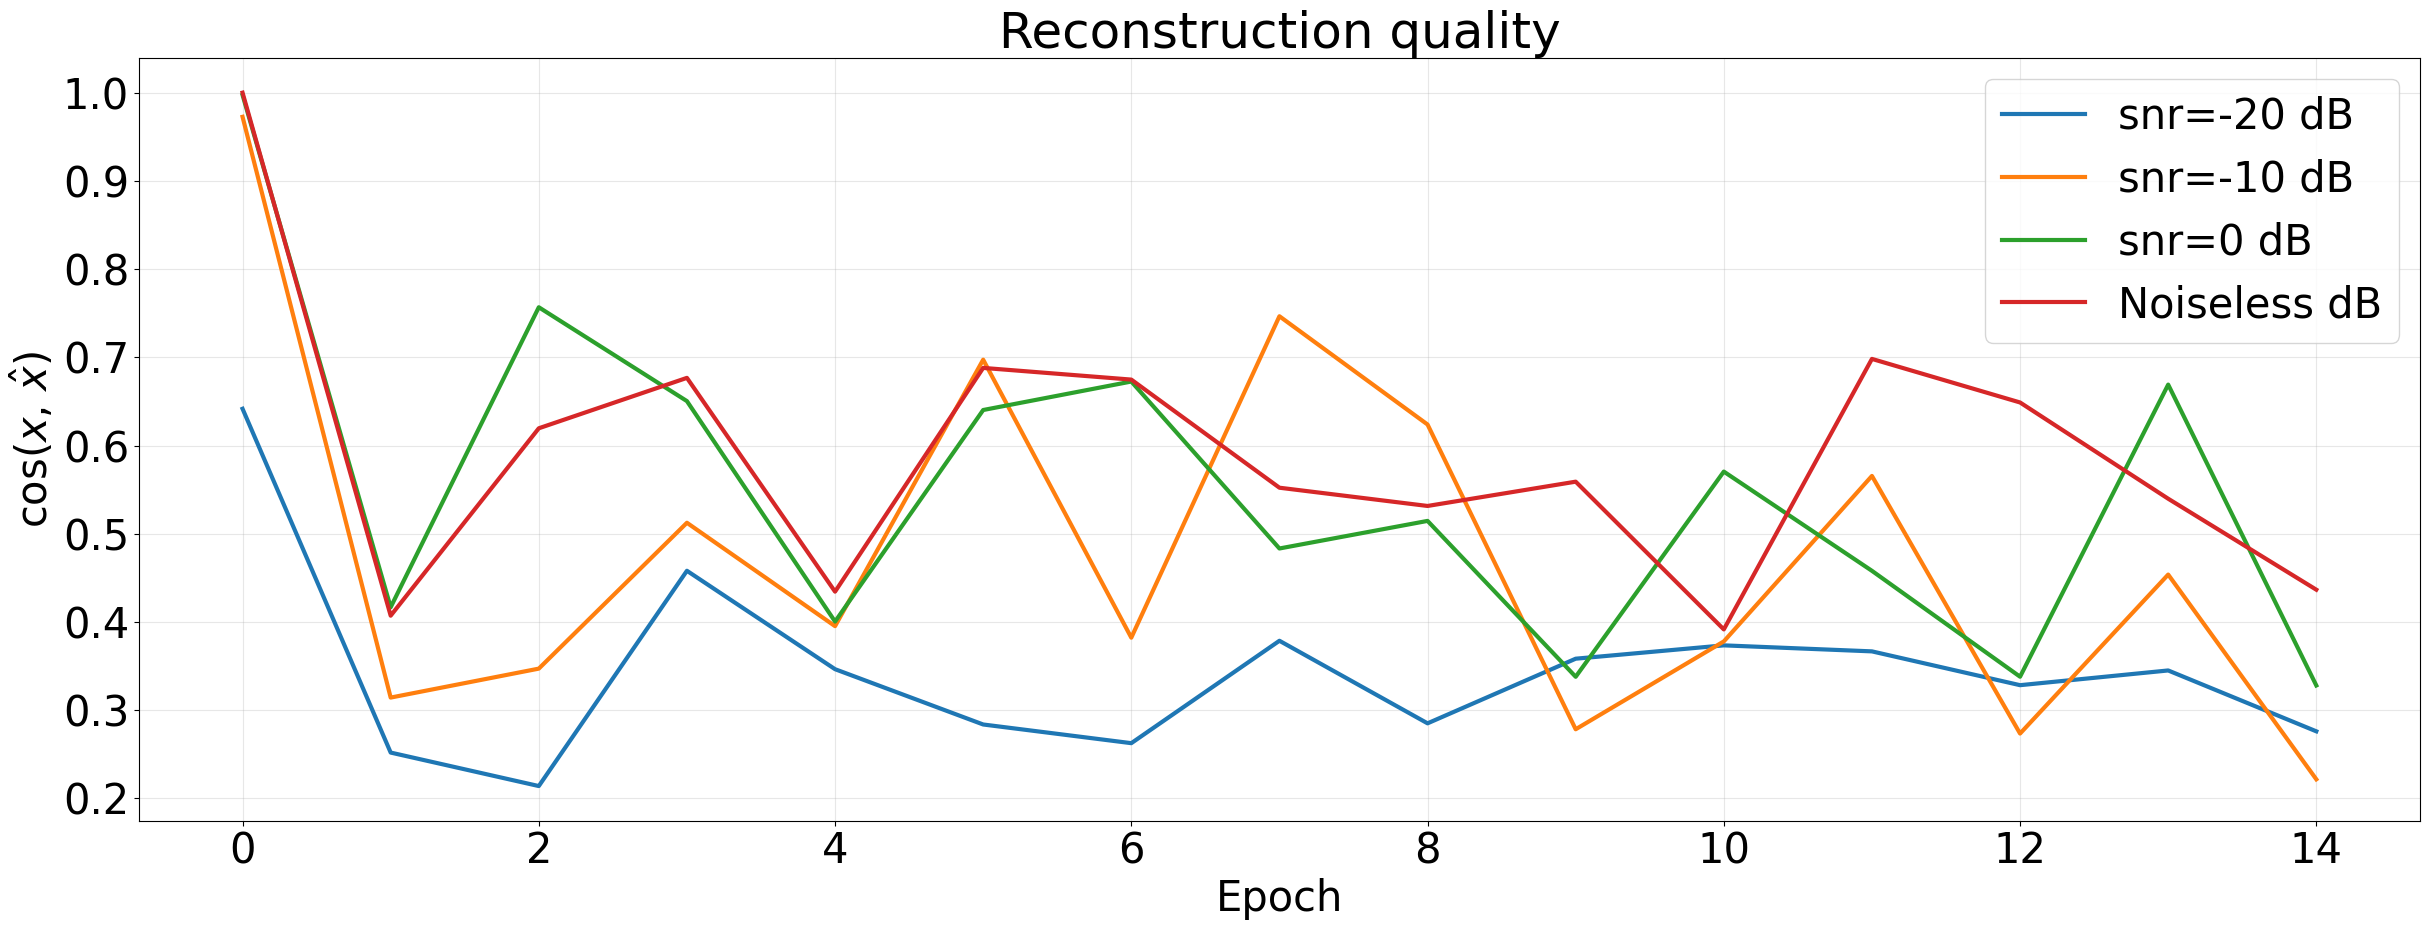

In [50]:
plt.figure(figsize=(25, 10))
plt.rcParams.update({'font.size': 30})

plt.plot(range(epochs), errors_snr_cos[0], linewidth=3, label=f'snr={int(10*np.log10(snr_arr[0]))} dB')
plt.plot(range(epochs), errors_snr_cos[1], linewidth=3, label=f'snr={int(10*np.log10(snr_arr[1]))} dB')
plt.plot(range(epochs), errors_snr_cos[2], linewidth=3, label=f'snr={int(10*np.log10(snr_arr[2]))} dB')
plt.plot(range(epochs), errors_snr_cos[3], linewidth=3, label=f'Noiseless dB')
#plt.plot(range(epochs), test_acc_per_epoch[0:epochs] , linestyle='-', linewidth=3, label='noisless')
plt.title('Reconstruction quality')
plt.xlabel('Epoch')
plt.ylabel(r'cos($x$, $\hat{x}$)')
plt.xticks(range(0, epochs, 2))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figure.png')